In [13]:
import numpy as np
import math
import matplotlib.pyplot as plt
def grs(e1, e2, e3, r):
    p = math.log(np.abs(e1-e2)/np.abs(e2-e3)) / math.log(r)
    return p

In [14]:
print(grs(0.00359899, 0.00298943, 0.00242438, 1.414))

0.21887477818865583


In [15]:
def grs1(e1, e2, r):
    p = math.log(e1/e2) / math.log(r)
    return p

In [19]:
print(grs1(0.00242439, 0.00193053,1.414))

0.6575361743847417


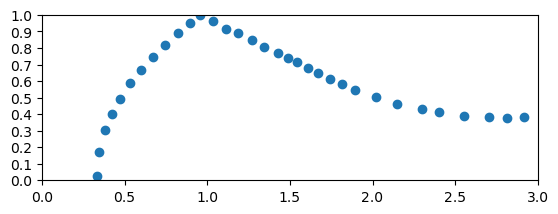

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import MultipleLocator


data = pd.read_csv('t1.csv')

x = data['x']
y = data['y']


x_major_locator = MultipleLocator(0.5)
y_major_locator = MultipleLocator(0.1)

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(0, 3)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 3.0, 0.5))
plt.yticks(np.arange(0, 1.0, 0.1))
plt.scatter(x, y, marker='o')
plt.gca().xaxis.set_major_locator(x_major_locator)
plt.gca().yaxis.set_major_locator(y_major_locator)


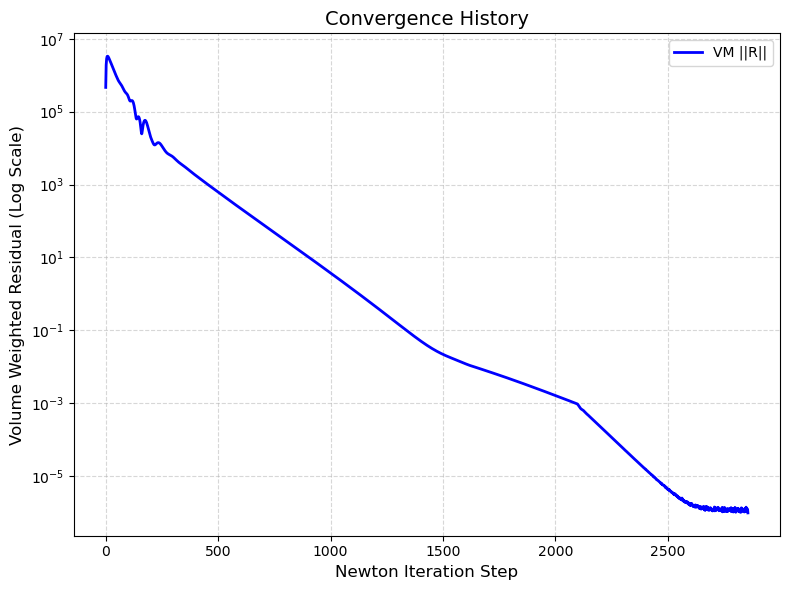

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame()
try:
    df = pd.read_csv("residual_history.csv")
    df.columns = df.columns.str.strip()  # Remove any leading/trailing whitespace from column names
except FileNotFoundError:
    print("Error: Could not find 'residual_history.csv'. Have you run your C++ solver?")
    exit()


step = df["Step"]
residual = df["Residual_VM"]


plt.figure(figsize=(8, 6))
plt.plot(step, residual, 'b-', linewidth=2, label="VM ||R||")


plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.title("Convergence History", fontsize=14)
plt.xlabel("Newton Iteration Step", fontsize=12)
plt.ylabel("Volume Weighted Residual (Log Scale)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.savefig("convergence_history.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取边界层分布
try:
    df_bl = pd.read_csv("bl_profile.csv")
except FileNotFoundError:
    print("Error: Could not find 'bl_profile.csv'.")
    raise

# 对数据按照 y 坐标排序，保证画线时点是按顺序连起来的
df_bl = df_bl.sort_values(by="y")

eta = df_bl["eta"]
u_uinf = df_bl["u"]
v_uinf = df_bl["v"]

# 绘制图形
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# 图1: u 速度剖面
ax1.plot(u_uinf, eta, 'bo-', markersize=4, label='Numerical U')
ax1.set_xlabel(r'$u / U_{\infty}$', fontsize=12)
ax1.set_ylabel(r'$\eta = y \sqrt{U_{\infty} / \nu x}$', fontsize=12)
ax1.set_title("Streamwise Velocity Profile", fontsize=14)
ax1.set_ylim(0, 8)  # Blasius 解在 eta=5 左右到达边界层外缘
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# 图2: v 速度剖面
ax2.plot(v_uinf, eta, 'ro-', markersize=4, label='Numerical V')
ax2.set_xlabel(r'$v / U_{\infty}$', fontsize=12)
ax2.set_ylabel(r'$\eta$', fontsize=12)
ax2.set_title("Normal Velocity Profile", fontsize=14)
ax2.set_ylim(0, 8)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig("blasius_comparison.png", dpi=300)
plt.show()

Analytical P1 (Upstream)   : 0.7023 psia
Analytical P2 (Downstream) : 0.2300 psia


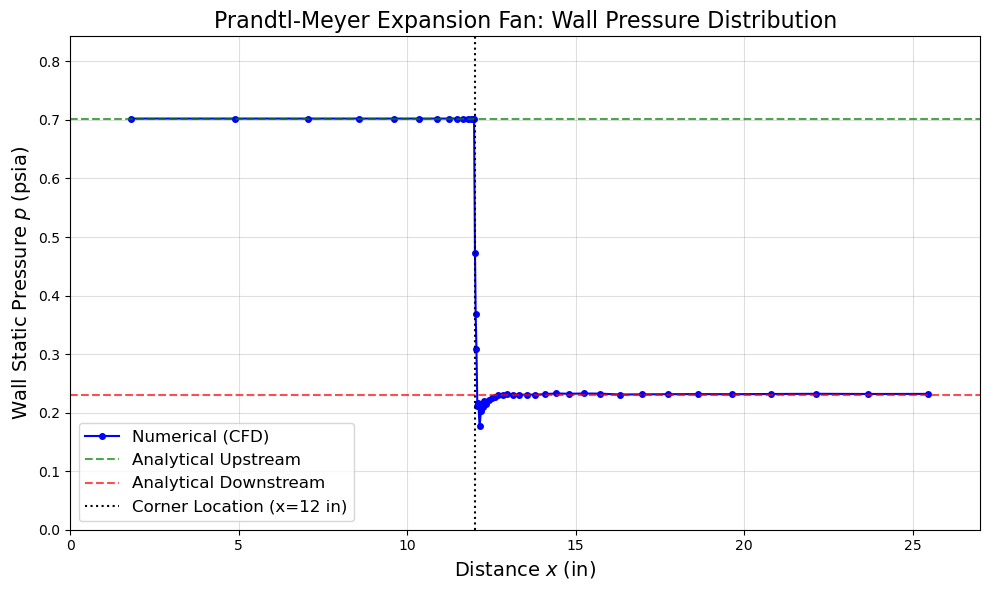

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# ==========================================
# 1. 理论解析解计算 (Prandtl-Meyer Exact Solution)
# ==========================================
def prandtl_meyer_function(M, gamma=1.4):
    """计算 Prandtl-Meyer 角度 (弧度)"""
    term1 = np.sqrt((gamma + 1) / (gamma - 1))
    term2 = np.arctan(np.sqrt((gamma - 1) / (gamma + 1) * (M**2 - 1)))
    term3 = np.arctan(np.sqrt(M**2 - 1))
    return term1 * term2 - term3

def get_downstream_Mach(M1, theta_turn_deg, gamma=1.4):
    """根据偏折角求解下游马赫数"""
    theta_turn_rad = np.radians(theta_turn_deg)
    nu1 = prandtl_meyer_function(M1, gamma)
    def objective(M2):
        return prandtl_meyer_function(M2, gamma) - (nu1 + theta_turn_rad)
    M2 = fsolve(objective, M1 + 0.5)[0] # 初始猜测值稍大于M1
    return M2

def static_pressure(M, P0, gamma=1.4):
    """等熵关系求静压"""
    return P0 / (1 + 0.5 * (gamma - 1) * M**2)**(gamma / (gamma - 1))

# 算例参数
gamma = 1.4
M_inf = 2.5
P0_psi = 12.0     # 总压 (psia)
x_corner_ft = 1.0 # 膨胀拐角的 x 坐标
x_corner_in = x_corner_ft * 12.0
theta_turn_deg = np.degrees(np.arctan(0.321539 / 1.2)) # 约 15°

# 分析上下游压力极限
p1 = static_pressure(M_inf, P0_psi, gamma)
M2 = get_downstream_Mach(M_inf, theta_turn_deg, gamma)
p2 = static_pressure(M2, P0_psi, gamma)

print(f"Analytical P1 (Upstream)   : {p1:.4f} psia")
print(f"Analytical P2 (Downstream) : {p2:.4f} psia")

# ==========================================
# 2. 读取并绘制求解器数值提取结果
# ==========================================
try:
    df_pm = pd.read_csv("pm_centerline.csv", skipinitialspace=True)
except FileNotFoundError:
    print("Error: Could not find 'pm_centerline.csv'. Please check if it was exported correctly.")
    raise

# 对坐标排序，保证绘制线条连续
df_pm = df_pm.sort_values(by="x_in")

x_num = df_pm["x_in"]
p_num = df_pm["p_psi"]

plt.figure(figsize=(10, 6))

# 绘制数值解 (点线)
plt.plot(x_num, p_num, 'bo-', markersize=4, label='Numerical (CFD)')

# 绘制理论阶跃基准线 (用作参考框)
plt.axhline(p1, color='green', linestyle='--', alpha=0.7, label='Analytical Upstream')
plt.axhline(p2, color='red', linestyle='--', alpha=0.7, label='Analytical Downstream')
plt.axvline(x_corner_in, color='k', linestyle=':', label='Corner Location (x=12 in)')

# 设置坐标轴和图例
plt.xlabel(r'Distance $x$ (in)', fontsize=14)
plt.ylabel(r'Wall Static Pressure $p$ (psia)', fontsize=14)
plt.title("Prandtl-Meyer Expansion Fan: Wall Pressure Distribution", fontsize=16)

# 坐标范围参考 (根据 x_domain = 2.2 * 12 = 26.4 in)
plt.xlim(0, 27)
plt.ylim(0, p1 * 1.2) # 让上限留出空间

plt.grid(True, linestyle='-', alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()

# 保存并显示
plt.savefig("pm_wall_pressure_comparison.png", dpi=300)
plt.show()